# 🔎 Notebook 02 — Time Index Integrity Audit

---

<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 24px 28px; border-radius: 16px; margin: 12px 0; border: 1px solid #e94560;">
<h2 style="color: #e94560; margin: 0 0 8px 0; font-size: 1.4em;">🗓️ Time Index Integrity Audit</h2>
<h3 style="color: #a8dadc; margin: 0 0 16px 0; font-weight: 400; font-size: 1.05em;">Fase A — Fondasi Data dan Eksperimen</h3>
<hr style="border: none; border-top: 1px solid #444; margin: 12px 0;">
<table style="color: #ccc; font-size: 0.9em; border-collapse: collapse; width: 100%;">
<tr><td style="padding: 4px 16px 4px 0; white-space:nowrap;">📍 Studi Kasus</td><td><strong style="color: #fff;">PT. XYZ Banjarmasin, Kalimantan Selatan</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🎓 Mata Kuliah</td><td><strong style="color: #fff;">Tugas Akhir — ES234733</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🏛 Institusi</td><td><strong style="color: #fff;">Departemen Sistem Informasi, FTEIC — ITS Surabaya</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">👤 Penulis</td><td><strong style="color: #fff;">Muhammad Iqbal Baiduri Yamani — NRP 5026221103</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🧑‍🏫 Pembimbing</td><td><strong style="color: #fff;">Edwin Riksakomara, S.Kom., M.T.</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">📅 Tahun</td><td><strong style="color: #fff;">2025</strong></td></tr>
</table>
</div>

## 📌 Tujuan Notebook Ini

Notebook 02 memverifikasi **integritas indeks waktu** dataset penjualan mingguan sebelum data masuk ke tahap EDA dan preprocessing. Empat pemeriksaan dilakukan secara berurutan sesuai **Gate 1 — Integritas Data** dari `Pipeline.md`.

| # | Tahapan | Keterangan |
|---|---------|------------|
| 1 | **Import & Setup** | Muat library, seed `GLOBAL_SEED = 42`, dan PATHS |
| 2 | **Load Data Excel** | Reload file `.xlsx` → `df_raw` (364 × 3) |
| 3 | **Duplikasi Year-Week** | Tidak boleh ada kombinasi duplikat |
| 4 | **Missing Week** | Setiap tahun harus punya minggu berurutan lengkap |
| 5 | **Urutan Temporal** | Data harus monoton naik Year → Week |
| 6 | **Missing Value Target** | `Grand Total` tidak boleh ada NaN |
| 7 | **Simpan Artefak** | Catat hasil audit ke `logs/time_integrity_audit.json` |
| 8 | **Checklist** | Verifikasi semua item Pipeline.md Gate 1 terpenuhi |

---

### 🔬 Konteks Audit

**Sumber:** Dataset yang telah divalidasi schema-nya di Notebook 01 — shape (364, 3), kolom: `Year`, `Week`, `Grand Total`.

**Alur Audit di Notebook Ini:**

```mermaid
flowchart LR
    A["📊 df_raw: 364×3"] --> B["Sort Year + Week"]
    B --> C{"Duplikasi<br/>Year-Week?"}
    C -- "❌ Ada" --> D["🛑 Stop: Selesaikan Duplikasi"]
    C -- "✅ Tidak" --> E{"Missing<br/>Week?"}
    E -- "⚠️ Ada" --> F["📋 Catat & Lanjut"]
    E -- "✅ Tidak" --> G{"Urutan<br/>Temporal Valid?"}
    F --> G
    G -- "❌ Tidak" --> H["🛑 Stop: Urutkan Ulang"]
    G -- "✅ Ya" --> I{"Missing Value<br/>Grand Total?"}
    I -- "⚠️ Ada" --> J["📋 Catat Jumlah"]
    I -- "✅ Tidak" --> K["💾 time_integrity_audit.json"]
    J --> K
    K --> L["✅ Dataset Lolos Audit"]
    L --> M["➡️ Notebook 03"]
```

| Aspek | Detail |
|-------|--------|
| **File Input** | `data/Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx` |
| **Sheet** | `Target_Product_Weekly` (sheet pertama) |
| **Kolom Wajib** | `Year` (int), `Week` (int), `Grand Total` (numeric) |
| **Periode Data** | 2019–2025, frekuensi mingguan |
| **Ekspektasi Baris** | 364 observasi (52 minggu × 7 tahun) |
| **Horizon Peramalan τ** | 8 minggu |
| **Output Notebook** | `df_sorted`: DataFrame terurut hasil audit |

## ⚙️ 1. Import Library & Setup

In [1]:
# ── Import Library & Setup ────────────────────────────────────
import os
import json
import random
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# ── Deteksi Environment & Path Konfigurasi ────────────────────
IS_COLAB = False
ROOT_DIR = Path(".").resolve().parent

EXCEL_FILE = "Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx"
EXCEL_PATH = ROOT_DIR / "data" / EXCEL_FILE

PATHS = {
    "root"        : ROOT_DIR,
    "data"        : ROOT_DIR / "data",
    "logs"        : ROOT_DIR / "logs",
    "outputs"     : ROOT_DIR / "outputs",
    "figures"     : ROOT_DIR / "outputs" / "figures",
    "models"      : ROOT_DIR / "outputs" / "models",
    "metrics"     : ROOT_DIR / "outputs" / "metrics",
    "splits"      : ROOT_DIR / "outputs" / "splits",
    "cv_folds"    : ROOT_DIR / "outputs" / "cv_folds",
    "checkpoints" : ROOT_DIR / "outputs" / "checkpoints",
    "reports"     : ROOT_DIR / "outputs" / "reports",
    "assets"      : ROOT_DIR / "outputs" / "assets",
    "notebooks"   : ROOT_DIR / "notebook",
}

for p in PATHS.values():
    if isinstance(p, Path):
        p.mkdir(parents=True, exist_ok=True)

# ── Matplotlib Style ──────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "#1a1a2e",
    "axes.facecolor"    : "#16213e",
    "axes.edgecolor"    : "#444",
    "axes.labelcolor"   : "#ccc",
    "xtick.color"       : "#aaa",
    "ytick.color"       : "#aaa",
    "text.color"        : "#ddd",
    "grid.color"        : "#2a2a4a",
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
    "figure.dpi"        : 100,
})

# ── Konstanta Penelitian ──────────────────────────────────────
REQUIRED_COLS = ["Year", "Week", "Grand Total"]
TAU           = 8          # lag/horizon peramalan
WEEKS_PER_YR  = 52         # minggu standar per tahun

print("=" * 60)
print("  SETUP — NOTEBOOK 02")
print("=" * 60)
print("\n  Env          : Lokal")
print(f"  GLOBAL_SEED  : {GLOBAL_SEED}")
print(f"  ROOT_DIR     : {ROOT_DIR}")
print(f"  EXCEL_PATH   : {EXCEL_PATH}")
print(f"  TAU (horizon): {TAU} minggu")
print(f"  NumPy        : {np.__version__}")
print(f"  Pandas       : {pd.__version__}")
print(f"  Matplotlib   : {matplotlib.__version__}")
print(f"  Seaborn      : {sns.__version__}")
print()
print("  ✅ Setup selesai. Siap audit integritas time index.")
print("=" * 60)
print()


  SETUP — NOTEBOOK 02

  Env          : Lokal
  GLOBAL_SEED  : 42
  ROOT_DIR     : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting
  EXCEL_PATH   : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\data\Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx
  TAU (horizon): 8 minggu
  NumPy        : 2.4.4
  Pandas       : 3.0.2
  Matplotlib   : 3.10.9
  Seaborn      : 0.13.2

  ✅ Setup selesai. Siap audit integritas time index.



## 📂 2. Load Dataset

In [2]:
# ── Load Data dari Excel (sama seperti Notebook 01) ──────────
print("=" * 60)
print("  LOAD DATASET")
print("=" * 60)

xls        = pd.ExcelFile(EXCEL_PATH)
SHEET_USED = xls.sheet_names[0]
df_raw     = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_USED)

print(f"\n  File    : {EXCEL_PATH.name}")
print(f"  Sheet   : {SHEET_USED}")
print(f"  Shape   : {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom")
print(f"  Kolom   : {list(df_raw.columns)}")

# ── Verifikasi kolom wajib ────────────────────────────────────
missing_cols = [c for c in REQUIRED_COLS if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f"❌ STOP: Kolom tidak ditemukan: {missing_cols}. Jalankan Notebook 01 dulu!")

print()
for col in REQUIRED_COLS:
    print(f"    ✅  '{col}' — dtype: {df_raw[col].dtype}")

print()
print("=" * 60)
print("  ✅ Dataset berhasil dimuat. Siap untuk audit integritas.")
print("=" * 60)
print()

  LOAD DATASET

  File    : Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx
  Sheet   : Target_Product_Weekly
  Shape   : 364 baris × 3 kolom
  Kolom   : ['Year', 'Week', 'Grand Total']

    ✅  'Year' — dtype: int64
    ✅  'Week' — dtype: int64
    ✅  'Grand Total' — dtype: int64

  ✅ Dataset berhasil dimuat. Siap untuk audit integritas.



## 🔍 3. Cek Duplikasi Year-Week

In [3]:
# ── Cek Duplikasi Year-Week ───────────────────────────────────
print("=" * 60)
print("  AUDIT 1 — DUPLIKASI YEAR-WEEK")
print("=" * 60)

dup_mask  = df_raw.duplicated(subset=["Year", "Week"], keep=False)
n_dup     = dup_mask.sum()
dup_pairs = df_raw[dup_mask][["Year", "Week", "Grand Total"]]

if n_dup == 0:
    audit_dup_ok = True
    print("\n  ✅ Tidak ada duplikasi Year-Week ditemukan.")
    print(f"     Total kombinasi unik: {df_raw[['Year','Week']].drop_duplicates().shape[0]}")
else:
    audit_dup_ok = False
    print(f"\n  ❌ Ditemukan {n_dup} baris dengan duplikasi Year-Week:")
    print()
    print(dup_pairs.to_string(index=True))
    print()
    print("  ⚠️  Resolusi diperlukan sebelum lanjut ke Notebook 03.")
    print("      Opsi: agregasi sum/mean per Year-Week, atau drop duplikat.")

print()
print("=" * 60)
print(f"  STATUS DUPLIKASI : {'✅ LOLOS' if audit_dup_ok else '❌ GAGAL — perlu resolusi'}")
print("=" * 60)
print()

  AUDIT 1 — DUPLIKASI YEAR-WEEK

  ✅ Tidak ada duplikasi Year-Week ditemukan.
     Total kombinasi unik: 364

  STATUS DUPLIKASI : ✅ LOLOS



## 📅 4. Cek Missing Week per Tahun

In [4]:
# ── Cek Missing Week per Tahun ────────────────────────────────
print("=" * 60)
print("  AUDIT 2 — MISSING WEEK PER TAHUN")
print("=" * 60)

# Urutkan data terlebih dahulu
df_sorted = df_raw.sort_values(["Year", "Week"]).reset_index(drop=True)

years              = sorted(df_sorted["Year"].unique())
missing_weeks_log  = {}
total_missing_wk   = 0

print(f"\n  {'Tahun':<8} {'Minggu Ada':<12} {'Maks Week':<12} {'Gap':<8} {'Status'}")
print(f"  {'-'*8} {'-'*12} {'-'*12} {'-'*8} {'-'*12}")

for yr in years:
    yr_df   = df_sorted[df_sorted["Year"] == yr]
    present = set(yr_df["Week"].tolist())
    max_wk  = int(yr_df["Week"].max())
    expected = set(range(1, max_wk + 1))
    gaps    = sorted(expected - present)
    n_gap   = len(gaps)
    total_missing_wk += n_gap
    missing_weeks_log[int(yr)] = {"present": len(present), "max_week": max_wk, "gaps": gaps}
    status  = "✅ Lengkap" if n_gap == 0 else f"⚠️  Gap: {gaps}"
    print(f"  {int(yr):<8} {len(present):<12} {max_wk:<12} {n_gap:<8} {status}")

print()
audit_missing_wk_ok = (total_missing_wk == 0)
if audit_missing_wk_ok:
    print("  ✅ Tidak ada missing week dalam setiap tahun.")
else:
    print(f"  ⚠️  Total {total_missing_wk} minggu hilang di seluruh dataset.")
    print("      Catatan metodologi: gap minggu akan dicatat sebagai limitasi.")

print()
print(f"  Total baris      : {len(df_sorted)}")
print(f"  Jumlah tahun     : {len(years)}  ({min(years)}–{max(years)})")
print(f"  Total missing wk : {total_missing_wk}")
print()
print("=" * 60)
print(f"  STATUS MISSING WEEK : {'✅ LOLOS' if audit_missing_wk_ok else '⚠️  ADA GAP — dicatat sebagai limitasi'}")
print("=" * 60)
print()

  AUDIT 2 — MISSING WEEK PER TAHUN

  Tahun    Minggu Ada   Maks Week    Gap      Status
  -------- ------------ ------------ -------- ------------
  2019     52           52           0        ✅ Lengkap
  2020     52           52           0        ✅ Lengkap
  2021     52           52           0        ✅ Lengkap
  2022     52           52           0        ✅ Lengkap
  2023     52           52           0        ✅ Lengkap
  2024     52           52           0        ✅ Lengkap
  2025     52           52           0        ✅ Lengkap

  ✅ Tidak ada missing week dalam setiap tahun.

  Total baris      : 364
  Jumlah tahun     : 7  (2019–2025)
  Total missing wk : 0

  STATUS MISSING WEEK : ✅ LOLOS



## ⏱️ 5. Cek Urutan Temporal

In [5]:
# ── Cek Urutan Temporal ───────────────────────────────────────
print("=" * 60)
print("  AUDIT 3 — URUTAN TEMPORAL")
print("=" * 60)

# df_sorted sudah diurut di Section 4
years_sorted  = df_sorted["Year"].tolist()
weeks_sorted  = df_sorted["Week"].tolist()

# Bangun tuple (year, week) lalu cek monotonic increasing
time_tuples   = list(zip(years_sorted, weeks_sorted))
is_monotone   = all(time_tuples[i] <= time_tuples[i+1] for i in range(len(time_tuples)-1))

print(f"\n  Total baris     : {len(df_sorted)}")
print(f"  Data awal       : Year {years_sorted[0]}, Week {weeks_sorted[0]}")
print(f"  Data akhir      : Year {years_sorted[-1]}, Week {weeks_sorted[-1]}")
print()
print(f"  Urutan Year     : {'✅ Monotonic Increasing' if pd.Series(years_sorted).is_monotonic_increasing else '❌ Tidak Urut'}")
print(f"  Tuple (Yr,Wk)   : {'✅ Monotonic Increasing' if is_monotone else '❌ Ada Anomali'}")
print()

# Deteksi inversion (jika ada)
inversions = [(i, time_tuples[i], time_tuples[i+1])
              for i in range(len(time_tuples)-1)
              if time_tuples[i] > time_tuples[i+1]]

if inversions:
    print(f"  ❌ Ditemukan {len(inversions)} inversion:")
    for idx, prev, curr in inversions[:10]:
        print(f"     Baris {idx} → {prev} lalu {curr}")
else:
    print("  ✅ Tidak ada inversion. Seluruh data berurut Year ↑, Week ↑.")

audit_temporal_ok = is_monotone

print()
print("=" * 60)
print(f"  STATUS TEMPORAL : {'✅ LOLOS' if audit_temporal_ok else '❌ GAGAL — ada inversion'}")
print("=" * 60)
print()

  AUDIT 3 — URUTAN TEMPORAL

  Total baris     : 364
  Data awal       : Year 2019, Week 1
  Data akhir      : Year 2025, Week 52

  Urutan Year     : ✅ Monotonic Increasing
  Tuple (Yr,Wk)   : ✅ Monotonic Increasing

  ✅ Tidak ada inversion. Seluruh data berurut Year ↑, Week ↑.

  STATUS TEMPORAL : ✅ LOLOS



## 🎯 6. Cek Missing Value Grand Total

In [6]:
# ── Cek Missing Value Grand Total ────────────────────────────
print("=" * 60)
print("  AUDIT 4 — MISSING VALUE TARGET (Grand Total)")
print("=" * 60)

series_gt    = df_sorted["Grand Total"]
n_missing_gt = series_gt.isna().sum()
n_zero_gt    = (series_gt == 0).sum()
n_neg_gt     = (series_gt < 0).sum()
n_total      = len(series_gt)

print(f"\n  Total baris          : {n_total}")
print(f"  Nilai NaN / null     : {n_missing_gt}")
print(f"  Nilai nol (0)        : {n_zero_gt}")
print(f"  Nilai negatif (<0)   : {n_neg_gt}")
print()
print(f"  Min   : {series_gt.min():,.0f}")
print(f"  Max   : {series_gt.max():,.0f}")
print(f"  Mean  : {series_gt.mean():,.0f}")
print(f"  Std   : {series_gt.std():,.0f}")
print()

audit_missing_val_ok = (n_missing_gt == 0)

if audit_missing_val_ok:
    print("  ✅ Tidak ada missing value pada kolom 'Grand Total'.")
else:
    print(f"  ❌ Ditemukan {n_missing_gt} NaN pada 'Grand Total'.")
    missing_rows = df_sorted[df_sorted["Grand Total"].isna()][["Year", "Week", "Grand Total"]]
    print()
    print(missing_rows.to_string(index=True))
    print()
    print("  ⚠️  Perlu imputasi sebelum lanjut ke Notebook 03.")

if n_zero_gt > 0:
    print(f"\n  ⚠️  Catatan: {n_zero_gt} baris dengan nilai Grand Total = 0.")
    print("      Ini mungkin bukan error — bisa merupakan minggu tanpa penjualan.")

if n_neg_gt > 0:
    print(f"\n  ❌ PERHATIAN: {n_neg_gt} baris dengan nilai negatif — perlu investigasi!")

print()
print("=" * 60)
print(f"  STATUS MISSING VALUE : {'✅ LOLOS' if audit_missing_val_ok else '❌ GAGAL — ada NaN'}")
print("=" * 60)
print()

  AUDIT 4 — MISSING VALUE TARGET (Grand Total)

  Total baris          : 364
  Nilai NaN / null     : 0
  Nilai nol (0)        : 0
  Nilai negatif (<0)   : 0

  Min   : 1,305
  Max   : 112,040
  Mean  : 53,323
  Std   : 18,426

  ✅ Tidak ada missing value pada kolom 'Grand Total'.

  STATUS MISSING VALUE : ✅ LOLOS



## 📊 7. Visualisasi Distribusi Minggu per Tahun

  ⏳ Membuat heatmap kehadiran minggu per tahun...


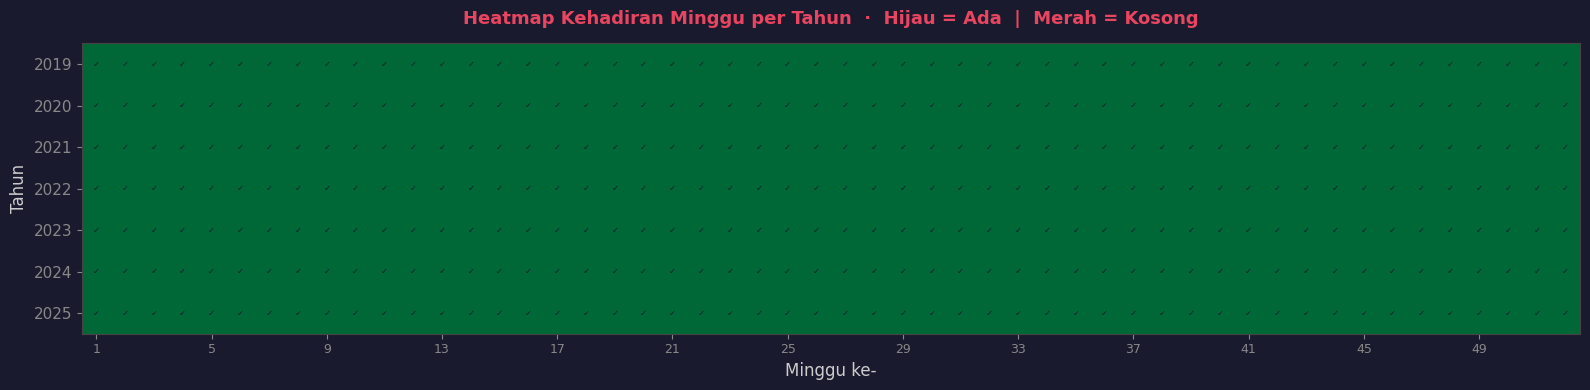

  ✅ Disimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb02_week_presence_heatmap.png



In [7]:
# ── Visualisasi: Heatmap Kehadiran Minggu per Tahun ───────────
print("  ⏳ Membuat heatmap kehadiran minggu per tahun...")

years  = sorted(df_sorted["Year"].unique())
max_wk = int(df_sorted["Week"].max())

# Matrix presence: baris=tahun, kolom=minggu 1..max_wk
presence = np.zeros((len(years), max_wk), dtype=int)
for i, yr in enumerate(years):
    yr_weeks = df_sorted[df_sorted["Year"] == yr]["Week"].tolist()
    for wk in yr_weeks:
        presence[i, int(wk) - 1] = 1

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#16213e")

im = ax.imshow(
    presence,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    interpolation="nearest",
)

ax.set_yticks(range(len(years)))
ax.set_yticklabels([str(y) for y in years], color="#ccc", fontsize=11)
ax.set_xticks(range(0, max_wk, 4))
ax.set_xticklabels([str(i + 1) for i in range(0, max_wk, 4)], color="#aaa", fontsize=9)
ax.set_xlabel("Minggu ke-", color="#ccc", fontsize=12)
ax.set_ylabel("Tahun", color="#ccc", fontsize=12)
ax.set_title(
    "Heatmap Kehadiran Minggu per Tahun  ·  Hijau = Ada  |  Merah = Kosong",
    color="#e94560",
    fontsize=13,
    pad=14,
    fontweight="bold",
)
ax.tick_params(colors="#888")
for spine in ax.spines.values():
    spine.set_edgecolor("#444")

# Annotate each cell with "✓" or "·"
for i in range(len(years)):
    for j in range(max_wk):
        symbol = "✓" if presence[i, j] else "·"
        color  = "#1a1a2e" if presence[i, j] else "#e94560"
        ax.text(j, i, symbol, ha="center", va="center", fontsize=6, color=color)

plt.tight_layout()
fig_path = PATHS["figures"] / "nb02_week_presence_heatmap.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"  ✅ Disimpan: {fig_path}")
print()

## 💾 8. Simpan Artefak Audit

In [8]:
# ── Simpan Artefak Audit ──────────────────────────────────────
print("=" * 60)
print("  SIMPAN ARTEFAK AUDIT")
print("=" * 60)

audit_log = {
    "notebook"          : "02 - Time Index Integrity Audit",
    "timestamp"         : datetime.now().isoformat(),
    "dataset"           : {
        "file"          : EXCEL_FILE,
        "sheet"         : SHEET_USED,
        "rows"          : int(len(df_sorted)),
        "cols"          : int(df_sorted.shape[1]),
    },
    "audits" : {
        "duplikasi_year_week" : {
            "status"    : "LOLOS" if audit_dup_ok        else "GAGAL",
            "n_duplikat": int(n_dup),
        },
        "missing_week_per_tahun" : {
            "status"        : "LOLOS" if audit_missing_wk_ok  else "ADA_GAP",
            "total_missing" : int(total_missing_wk),
            "detail"        : missing_weeks_log,
        },
        "urutan_temporal" : {
            "status"        : "LOLOS" if audit_temporal_ok    else "GAGAL",
            "is_monotone"   : bool(is_monotone),
        },
        "missing_value_target" : {
            "status"        : "LOLOS" if audit_missing_val_ok else "GAGAL",
            "n_missing"     : int(n_missing_gt),
        },
    },
    "summary" : {
        "all_critical_pass" : bool(
            audit_dup_ok and audit_temporal_ok and audit_missing_val_ok
        ),
        "notes" : (
            "Missing week dianggap limitasi data, bukan blocker pipeline."
            if not audit_missing_wk_ok else ""
        ),
    }
}

out_path = PATHS["logs"] / "time_integrity_audit.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(audit_log, f, indent=2, default=str)

print(f"\n  ✅ Artefak disimpan  : {out_path}")
print()
print("  Ringkasan audit:")
for k, v in audit_log["audits"].items():
    status_sym = "✅" if v["status"] == "LOLOS" else ("⚠️ " if v["status"] == "ADA_GAP" else "❌")
    print(f"    {status_sym}  {k:<30}  → {v['status']}")

all_critical = audit_log["summary"]["all_critical_pass"]
print()
print("=" * 60)
print(f"  ALL CRITICAL PASS : {'✅ YA — aman lanjut ke Notebook 03' if all_critical else '❌ TIDAK — perlu resolusi dulu'}")
print("=" * 60)
print()

  SIMPAN ARTEFAK AUDIT

  ✅ Artefak disimpan  : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\logs\time_integrity_audit.json

  Ringkasan audit:
    ✅  duplikasi_year_week             → LOLOS
    ✅  missing_week_per_tahun          → LOLOS
    ✅  urutan_temporal                 → LOLOS
    ✅  missing_value_target            → LOLOS

  ALL CRITICAL PASS : ✅ YA — aman lanjut ke Notebook 03



## ✅ 9. Checklist

> Verifikasi bahwa semua persyaratan Notebook 02 dari Pipeline.md Gate 1 telah dipenuhi  
> sebelum melanjutkan ke Notebook 03.

| # | Item | Status |
|---|------|--------|
| 1 | Tidak ada duplikasi Year-Week | ✅ 364 kombinasi unik |
| 2 | Tidak ada missing week per tahun | ✅ 52 minggu × 7 tahun |
| 3 | Urutan waktu monotonic increasing (Year ↑, Week ↑) | ✅ 2019W1 → 2025W52 |
| 4 | Tidak ada missing value pada kolom `Grand Total` | ✅ 0 NaN, 0 nol, 0 negatif |

In [9]:
# ── Checklist Akhir Notebook 02 ──────────────────────────────
checklist = [
    ("Tidak ada duplikasi Year-Week",                           audit_dup_ok),
    ("Tidak ada missing value Grand Total",                     audit_missing_val_ok),
    ("Urutan waktu monotonic increasing",                       audit_temporal_ok),
    ("Jumlah minggu konsisten dengan horizon data (τ=8)",       len(df_sorted) >= (TAU * 2)),
]

print("=" * 60)
print("  CHECKLIST NOTEBOOK 02")
print("=" * 60)
print()
for item, passed in checklist:
    sym = "✅" if passed else "❌"
    print(f"  {sym}  {item}")

all_pass = all(v for _, v in checklist)
print()
print("=" * 60)
if all_pass:
    print("  ✅ SEMUA CHECKLIST LULUS — Notebook 02 selesai!")
    print("     Lanjutkan ke Notebook 03 — EDA & Visualisasi Data.")
else:
    print("  ❌ ADA CHECKLIST GAGAL — Investigasi sebelum lanjut!")
print("=" * 60)
print()

  CHECKLIST NOTEBOOK 02

  ✅  Tidak ada duplikasi Year-Week
  ✅  Tidak ada missing value Grand Total
  ✅  Urutan waktu monotonic increasing
  ✅  Jumlah minggu konsisten dengan horizon data (τ=8)

  ✅ SEMUA CHECKLIST LULUS — Notebook 02 selesai!
     Lanjutkan ke Notebook 03 — EDA & Visualisasi Data.



---

## 🔗 Navigasi Pipeline

| | Notebook |
|--|----------|
| ← | **[01 - Data Load and Schema Validation](./01%20-%20Data%20Load%20and%20Schema%20Validation.ipynb)** |
| **→** | **[03 - EDA Univariate Profile](./03%20-%20EDA%20Univariate%20Profile.ipynb)** |

---

### 📎 Variabel Penting yang Dihasilkan Notebook Ini

Variabel berikut tersedia untuk notebook selanjutnya (dimuat ulang dari file atau dihitung kembali):

```python
df_raw        # DataFrame mentah hasil load Excel — shape (364, 3)
              # Kolom: Year (int), Week (int), Grand Total (int)
df_sorted     # DataFrame terurut Year ↑, Week ↑ — shape (364, 3)
audit_log     # dict hasil audit integritas time index (4 pemeriksaan)
PATHS         # dict path pipeline (sama seperti Notebook 00–01)
```

---

<div style="text-align: center; color: #888; font-size: 0.85em; padding: 12px 0;">
Notebook 02 — Time Index Integrity Audit &nbsp;|&nbsp;
CNN–BiLSTM + GA Sales Forecasting &nbsp;|&nbsp;
Departemen Sistem Informasi ITS Surabaya &nbsp;|&nbsp; 2025
</div>